In [1]:
from hydra import initialize, compose
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.patches import Patch
import re
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import defaultdict, Counter
from itertools import product
from ergochemics.draw import draw_molecule, draw_reaction
from IPython.display import SVG

with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

def find_between_rules(s):
    match = re.search(r'_rules_(.+?)_rules_', s)
    return match.group(1) if match else None

def check_for_kr_match(lhs: Counter, rhs: Counter, kr_counts: list[tuple[Counter, Counter]]):
    for kr_lhs, kr_rhs in kr_counts:
        possible = True
        for lsmi, lcount in lhs.items():
            if kr_lhs.get(lsmi, 0) != lcount:
                possible = False
                break
        if not possible:
            continue
        for rsmi, rcount in rhs.items():
            if kr_rhs.get(rsmi, 0) != rcount:
                possible = False
                break
        if possible:
            return True
    return False

In [2]:
cutoff_date = 2015
pub = pl.read_parquet(Path(cfg.raw_data) / "rxn_pub_dates.parquet")
pub = pub.explode("publication_dates")
pub = pub.group_by("id").agg(
    pl.col("publication_dates").min(),
    pl.col("smarts").first()
).filter(pl.col("publication_dates") >= cutoff_date).rename({"publication_dates": "pub_date"})
tot_pub_rxns = pub.shape[0]
print(f"Total reactions with publication date >= {cutoff_date}: {tot_pub_rxns:,}")
pub.head()

Total reactions with publication date >= 2015: 4,466


id,pub_date,smarts
str,i32,str
"""68ca64a6dcbe4a1eab8f86b16b51ba…",2020,"""CC(C)(COP(=O)(O)OP(=O)(O)OCC1O…"
"""27df7622c281b904b0aa0aa4b8320c…",2017,"""*OCC(CO*)O*.CCCCCC=CCC=CCCCCCC…"
"""2b948ea6d1a77d52df39cf43fab8b3…",2015,"""C=C(CCC(C)C1CCC2(CO)C3=C(CCC12…"
"""83171b7288b2ceacd4995c2b6777b3…",2017,"""C=CC(C)(C)c1c(O)c2c3c(c(O)cc(C…"
"""74a0fd8b25fd1b77a9e25ed9fb00da…",2022,"""O=C(CO)COP(=O)(O)O.O=CCO>>O=C(…"


In [3]:
input_cts_lb = 3
metrics = []
for fn in (Path(cfg.interim_data) / "std_pickaxe_rxns").glob("*.parquet"):
    _name = find_between_rules(fn.stem)

    if "direct_mcsa_only" in fn.stem:
        continue

    suffix = f"_before_{cutoff_date}" if "retrobiocat" not in _name else ""

    post_mappings_fn = Path(cfg.raw_data) / "mappings" / f"mappings_known_reactions_after_2015_x_{_name}_rules{suffix}.parquet"
    if post_mappings_fn.exists():
        maps = pl.read_parquet(
            Path(cfg.raw_data) / "mappings" / f"mappings_known_reactions_after_2015_x_{_name}_rules{suffix}.parquet"
        )
    else:
        maps = pl.read_parquet(
            Path(cfg.raw_data) / "mappings" / f"mapped_known_reactions_x_{_name}_rules{suffix}.parquet"
        )
    
    pred = pl.read_parquet(fn) # Expansion

    if "mechinferred" in _name:
        input_maps = pl.read_parquet(
            Path(cfg.mappings) / f"mapped_known_reactions_x_{_name}_rules{suffix}.parquet"
        )
        op_input_cts = input_maps.group_by("rule_id").agg(pl.len().alias("input_count"))
        op_input_cts = op_input_cts.filter(pl.col("input_count") >= input_cts_lb)
        maps = maps.join(op_input_cts, on="rule_id", how="inner")
        pred = pred.join(op_input_cts, on="rule_id", how="inner")

    if "evodex" in _name:
        maps = maps.with_columns(
            pl.col("smarts").str.split(">>").list.get(0).alias("lhs"),
            pl.col("smarts").str.split(">>").list.get(1).alias("rhs"),
            pl.col("rule").str.split(">>").list.get(0).alias("lhs_rule"),
            pl.col("rule").str.split(">>").list.get(1).alias("rhs_rule")
        ).with_columns(
            pl.col("lhs").str.split(".").len().alias("n_rcts"),
            pl.col("rhs").str.split(".").len().alias("n_pdts"),
            pl.col("lhs_rule").str.split(".").len().alias("n_rcts_rule"),
            pl.col("rhs_rule").str.split(".").len().alias("n_pdts_rule"),
        ).filter(
            (pl.col("n_rcts_rule") <= pl.col("n_rcts")) | (pl.col("n_pdts_rule") <= pl.col("n_pdts"))
        )
    n_rxns_constr = len(maps.unique(subset=["smarts"]))
    maps = maps.unique(subset=["rxn_id"])
    pred = pred.unique(subset=["id"])
    
    _n_pub_recovered = maps.join(pub, left_on="rxn_id", right_on="id", how="inner").shape[0]

    metrics.append(
        {
            "name": _name,
            "num_rxns": len(pred),
            "num_rxns_constr": n_rxns_constr,
            "num_pub_rxns": _n_pub_recovered,
            "frac_pub_rxns": _n_pub_recovered / tot_pub_rxns,
            "fn": fn,
        }
    )

metrics.append(
    {
        "name": "rc_plus_0",
        "num_rxns": 7666721,
        "num_rxns_constr": 7666721,
        "num_pub_rxns": 2690,
        "frac_pub_rxns": 2690 / tot_pub_rxns,
         "fn": None,
    }
)

# metrics.append(
#     {
#         "name": "mechinferred_dt_059_direct_mcsa_only",
#         "num_rxns": 47_327,
#         "num_pub_rxns": 1_183,
#         "frac_pub_rxns": 1_183 / tot_pub_rxns,
#          "fn": None,
#     }
# )

# metrics.append(
#     {
#         "name": "mechinferred_dt_035_direct_mcsa_only",
#         "num_rxns": 40_109,
#         "num_pub_rxns": 780,
#         "frac_pub_rxns": 780 / tot_pub_rxns,
#          "fn": None,
#     }
# )

metrics = pl.DataFrame(metrics).sort("frac_pub_rxns", descending=True)
metrics.head(10)

name,num_rxns,num_rxns_constr,num_pub_rxns,frac_pub_rxns,fn
str,i64,i64,i64,f64,object
"""evodex_Bm""",52168,7038,3245,0.726601,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_evodex_Bm_rules_before_2015_w_coreactants_aplusb_True.parquet
"""rc_plus_0""",7666721,7666721,2690,0.602329,null
"""mechinferred_dt_932""",425783,3105,2498,0.559337,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_932_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Cm""",12633,6246,2423,0.542544,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_evodex_Cm_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Dm""",7470,6182,2405,0.538513,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_evodex_Dm_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Em""",5799,5791,2348,0.52575,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_evodex_Em_rules_before_2015_w_coreactants_aplusb_True.parquet
"""rdchiral""",173551,18229,2274,0.50918,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_rdchiral_rules_before_2015_w_coreactants_aplusb_True.parquet
"""imt""",1225336,17236,2242,0.502015,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_imt_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_069""",106469,3569,2170,0.485893,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_069_rules_before_2015_w_coreactants_aplusb_True.parquet


In [259]:
Rs = [0, 1, 2, 3, 4]
dts = ['932', '069', '021', '009', '005']
dts_dmo = ['961', '244', '106', '059', '035']
others = ['mechinformed', 'rdchiral', 'imt', "evodex_Bm", "evodex_Cm", "evodex_Dm", "evodex_Em", "retrobiocat"]
mechinferred_template_sizes = defaultdict(list)
rcr_template_sizes = defaultdict(list)
dmo_template_sizes = defaultdict(list)
bad_rules = {'rcr': set(), 'mechinferred': set()}
rcr_rules = []
other_rules = []
other_template_sizes = defaultdict(list)

for dt in dts:
    df = pl.read_csv(
        Path(cfg.rules) / f"mechinferred_dt_{dt}_rules_before_{cutoff_date}.csv",
    )
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        mechinferred_template_sizes[dt].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for dt in dts_dmo:
    df = pl.read_csv(
        Path(cfg.rules) / f"mechinferred_dt_{dt}_rules_before_{cutoff_date}_direct_mcsa_only.csv",
    )
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        dmo_template_sizes[dt].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for R in Rs:
    if R == 0:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_0_rules_before_{cutoff_date}.csv",
        )
    else:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_{R}_rules_before_{cutoff_date}.csv",
        )
    rcr_rules.append(df)
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        rcr_template_sizes[R].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for other in others:
    if other == 'imt':
        df = pl.read_csv(
            Path(cfg.rules) / f"imt_rules_before_{cutoff_date}.csv",
        )
    elif other == "retrobiocat":
        df = pl.read_csv(
            Path(cfg.rules) / f"retrobiocat_rules.csv",
        )
    else:
        df = pl.read_csv(
            source=Path(cfg.rules) / f"{other}_rules_before_{cutoff_date}.csv",
            ignore_errors=True,
        )
    other_rules.append(df)
    for row in df.iter_rows(named=True):
            sma = row["smarts"]
            rxn = AllChem.ReactionFromSmarts(sma)
            other_template_sizes[other].append(
                sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
            )

median_template_size = {}

for name in metrics["name"].unique().to_list():
    vals = None

    if name.startswith("mechinferred_dt_") and "direct_mcsa_only" not in name:
        dt = name.split("_")[-1]
        vals = mechinferred_template_sizes.get(dt, [])
    elif name.startswith("rc_plus_"):
        R = int(name.split("_")[-1])
        vals = rcr_template_sizes.get(R, [])
    elif name.startswith("mechinferred_dt_") and "direct_mcsa_only" in name:
        dt = name.split("_")[2]
        vals = dmo_template_sizes.get(dt, [])
    else:
        vals = other_template_sizes.get(name, [])

    median_template_size[name] = pl.Series(vals).median() if vals else None

median_template_size


{'rc_plus_1': 8.0,
 'rc_plus_3': 17.0,
 'mechinferred_dt_005': 40.0,
 'rc_plus_2': 13.0,
 'mechinferred_dt_035_direct_mcsa_only': 49.0,
 'evodex_Cm': 9.0,
 'rc_plus_4': 21.0,
 'retrobiocat': 6.0,
 'evodex_Bm': 4.0,
 'rc_plus_0': 5.0,
 'mechinformed': 7.0,
 'evodex_Dm': 10.0,
 'mechinferred_dt_059_direct_mcsa_only': 38.0,
 'evodex_Em': 11.0,
 'rdchiral': 10.0,
 'mechinferred_dt_021': 30.0,
 'imt': 3.0,
 'mechinferred_dt_932': 4.0,
 'mechinferred_dt_069': 18.0,
 'mechinferred_dt_009': 34.0}

In [257]:
# Plot cfg

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16,
})

exp_labels = {
    'mechinformed': "Distilled",
    'mechinferred_dt_932': "Learned >0.932",
    'mechinferred_dt_069': "Learned >0.069",
    'mechinferred_dt_021': "Learned >0.021",
    'mechinferred_dt_009': "Learned >0.009",
    'mechinferred_dt_005': "Learned >0.005",
    'mechinferred_dt_961_direct_mcsa_only': "Learned >0.961 (direct MCSA only)",
    'mechinferred_dt_244_direct_mcsa_only': "Learned >0.244 (direct MCSA only)",
    'mechinferred_dt_106_direct_mcsa_only': "Learned >0.106 (direct MCSA only)",
    'mechinferred_datat_059_direct_mcsa_only': "Learned >0.059 (direct MCSA only)",
    'mechinferred_dt_035_direct_mcsa_only': "Learned >0.035 (direct MCSA only)",
    'rc_plus_0': "RC + 0",
    'rc_plus_1': "RC + 1",
    'rc_plus_2': "RC + 2",
    'rc_plus_3': "RC + 3",
    'rc_plus_4': "RC + 4",
    'imt': "Pathway-level clustering",
    'rdchiral': "RDChiral",
    "retrobiocat": "RetroBioCat",
    "evodex_Bm": "EVODEX Bm",
    "evodex_Cm": "EVODEX Cm",
    "evodex_Dm": "EVODEX Dm",
    "evodex_Em": "EVODEX Em"
}

colors = {
    'mechinformed': matplotlib.colors.to_rgba("green"),
    'mechinferred_dt_932': matplotlib.colors.to_rgba("purple", alpha=0.3),
    'mechinferred_dt_069': matplotlib.colors.to_rgba("purple", alpha=0.45),
    'mechinferred_dt_021': matplotlib.colors.to_rgba("purple", alpha=0.6),
    'mechinferred_dt_009': matplotlib.colors.to_rgba("purple", alpha=0.85),
    'mechinferred_dt_005': matplotlib.colors.to_rgba("purple", alpha=1.0),
    'mechinferred_dt_961_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.3),
    'mechinferred_dt_244_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.45),
    'mechinferred_dt_106_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.6),
    'mechinferred_datat_059_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.85),
    'mechinferred_dt_035_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=1.0),
    'rc_plus_0': matplotlib.colors.to_rgba("black", alpha=0.3),
    'rc_plus_1': matplotlib.colors.to_rgba("black", alpha=0.45),
    'rc_plus_2': matplotlib.colors.to_rgba("black", alpha=0.6),
    'rc_plus_3': matplotlib.colors.to_rgba("black", alpha=0.85),
    'rc_plus_4': matplotlib.colors.to_rgba("black", alpha=1.0),
    'imt': matplotlib.colors.to_rgba("darkorange"),
    'rdchiral': matplotlib.colors.to_rgba("blue"),
    "retrobiocat": matplotlib.colors.to_rgba("cyan"),
    "evodex_Bm": matplotlib.colors.to_rgba("red", alpha=0.3),
    "evodex_Cm": matplotlib.colors.to_rgba("red", alpha=0.45),
    "evodex_Dm": matplotlib.colors.to_rgba("red", alpha=0.6),
    "evodex_Em": matplotlib.colors.to_rgba("red", alpha=0.9),
}

exp_names = list(exp_labels.keys())

legend_elements = [
    Patch(facecolor=col, edgecolor='w', label=exp_labels[name])
    for name, col in colors.items()
]

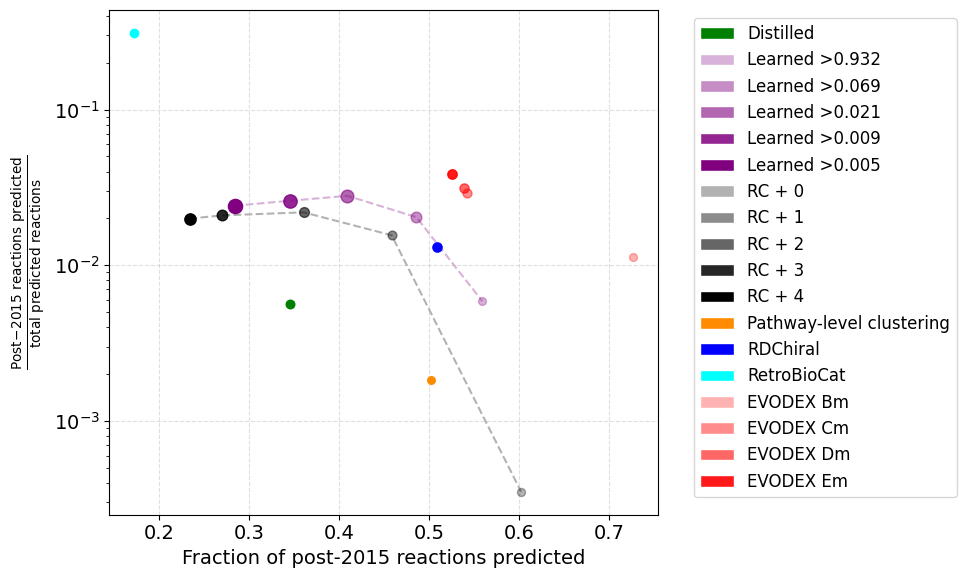

In [260]:
fig, ax = plt.subplots(figsize=(10, 6))
dot_slope = 2
dot_intercept = 24

legend_elements = [
    Patch(facecolor=col, edgecolor='w', label=exp_labels[name])
    for name, col in colors.items()
    if "direct_mcsa_only" not in name
]

# collect grouped points for connecting lines
mechinferred_data = []
rcr_data = []

for row in metrics.iter_rows(named=True):
    name = row["name"]
    if "direct_mcsa_only" in name:
        continue
    
    if name not in exp_labels:
        continue

    x = row["frac_pub_rxns"]
    y = row["num_pub_rxns"] / row["num_rxns"]

    template_size = median_template_size.get(name)
    marker_size = (
        dot_slope * template_size + dot_intercept
        if template_size is not None
        else dot_intercept
    )

    if name.startswith("mechinferred_dt_"):
        mechinferred_data.append((x, y))
    elif name.startswith("rc_plus_"):
        rcr_data.append((x, y))

    ax.scatter(
        x,
        y,
        color=colors[name],
        s=marker_size,
        label=exp_labels[name],
        zorder=3,
    )

# connect purple dots (mechinferred)
if mechinferred_data:
    mechinferred_data = sorted(mechinferred_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in mechinferred_data],
        [p[1] for p in mechinferred_data],
        color="purple",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# connect black dots (rc_plus)
if rcr_data:
    rcr_data = sorted(rcr_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in rcr_data],
        [p[1] for p in rcr_data],
        color="black",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

ax.set_xlabel(f"Fraction of post-{cutoff_date} reactions predicted")
ax.set_ylabel(
    rf"$\frac{{\mathrm{{Post\!-\!{cutoff_date}\ reactions\ predicted}}}}{{\mathrm{{total\ predicted\ reactions}}}}$"
)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(Path(cfg.figures) / f"after_{cutoff_date}_generative_performance.svg")
plt.show()


In [4]:
from ergochemics.draw import draw_reaction, draw_molecule
from ergochemics.standardize import standardize_reaction, hash_reaction
from IPython.display import SVG
from rdkit import Chem

def rm_hs(rxn: str) -> str:
    lhs, rhs = rxn.split('>>')
    lhs = Chem.MolToSmiles(Chem.RemoveHs(Chem.MolFromSmiles(lhs)))
    rhs = Chem.MolToSmiles(Chem.RemoveHs(Chem.MolFromSmiles(rhs)))
    return f"{lhs}>>{rhs}"

def standardize_and_hash(rxn: str) -> tuple:
    standardized = standardize_reaction(rxn)
    hashed = hash_reaction(standardized)
    return hashed

In [5]:
letters = ["C", "D", "E"]
missed = []
for letter in letters:
    print(f"Processing letter: {letter}")
    maps = pl.read_parquet(
        f"../data/raw/mappings/mappings_known_reactions_after_2015_x_evodex_{letter}m_rules_before_2015.parquet"
    )
    exceeds = set()
    for row in maps.iter_rows(named=True):
        smarts = row['smarts']
        lhs = smarts.split(">>")[0]
        n_rcts = len(lhs.split("."))
        n_rule_rcts = len(row['rule'].split(">>")[0].split("."))
        if n_rule_rcts > n_rcts:
            exceeds.add(row["rxn_id"])

        n_pdts = len(smarts.split(">>")[1].split("."))
        n_rule_pdts = len(row['rule'].split(">>")[1].split("."))
        if n_rule_pdts > n_pdts:
            exceeds.add(row["rxn_id"])

    print(len(exceeds))
    df = maps.join(other=pub, left_on='rxn_id', right_on='id', how='inner', suffix='_true').with_columns(
        pl.col("smarts").map_elements(standardize_reaction, return_dtype=pl.String).alias("std_smarts")
    )

    # unmatched_pdts = set()
    # for unique_id in set(df['rxn_id'].to_list()):
    #     gen_smarts = df.filter(pl.col('rxn_id') == unique_id)['std_smarts'].to_list()
    #     gen_pdts = set()
    #     for smarts in gen_smarts:
    #         pdts = smarts.split(">>")[1].split(".")
    #         gen_pdts.update(pdts)

    #     true_pdts = set(df.filter(pl.col("rxn_id") == unique_id).row(0, named=True)['smarts_true'].split(">>")[1].split("."))

    #     if len(true_pdts - gen_pdts) > 0:
    #         unmatched_pdts.add(unique_id)

    #     for elt in true_pdts - gen_pdts:
    #         missed.append(elt)

    
    # print(f"N rxns with matched products: {len(set(df['rxn_id'].to_list()) - unmatched_pdts)}")

    # df = df.with_columns(
    #     pl.col("smarts").map_elements(standardize_and_hash, return_dtype=pl.String).alias("gen_id")
    # )
    # exact_matches = df.filter(pl.col("gen_id") == pl.col("rxn_id"))
    # print(f"Exact matches: {len(exact_matches)}")
df.head()

Processing letter: C
100
Processing letter: D
95
Processing letter: E
81


rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,pub_date,smarts_true,std_smarts
str,str,str,str,str,str,i32,str,str
"""d6a969a9ca5894c986832d2cfa4515…","""[H]OC1([H])C([H])([H])C(=O)OC(…",null,"""[#6:71]-[#8:70]-[#6](=[#8])-[#…","""18,19,20,21,22>>""","""EVODEX.2-Em124""",2017,"""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…","""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…"
"""d6a969a9ca5894c986832d2cfa4515…","""[H]OC1([H])C([H])([H])C(=O)OC(…",null,"""[#6:3]-[#6:1](-[#8]-[#6])(-[#6…","""17,18,19,20,26,49;0,1,2>>""","""EVODEX.2-Em259""",2017,"""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…","""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…"
"""d6a969a9ca5894c986832d2cfa4515…","""[H]OC1([H])C([H])([H])C(=O)OC(…",null,"""[#6:3]-[#6:1](=[#8:4])-[#8]-[#…","""22,20,21,19,18;0,1,2>>""","""EVODEX.2-Em25""",2017,"""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…","""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…"
"""d6a969a9ca5894c986832d2cfa4515…","""[H]OC1([H])C([H])([H])C(=O)OC(…",null,"""[#6]-[#6](-[#6])(-[#8:24]-[#6:…","""17,18,26,19,20,21,22,49>>""","""EVODEX.2-Em508""",2017,"""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…","""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…"
"""d6a969a9ca5894c986832d2cfa4515…","""[H]OC1([H])C([H])([H])C(=O)OC(…",null,"""[#6:3]-[#6:1](-[#8:81]-[#6:82]…","""17,18,19,20,26,49;0,1,2>>""","""EVODEX.2-Em62""",2017,"""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…","""CCC(C)C(=O)OC1CCC=C2C=CC(C)C(C…"


In [65]:
unique_missed = list(set(missed))
missed_cts = Counter(missed)
print(len(unique_missed))

216


In [25]:
fn

PosixPath('/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_244_rules_before_2015_direct_mcsa_only_w_coreactants_aplusb_True.parquet')

In [27]:
letter

'E'

In [96]:
pred = pl.read_parquet(
    Path(f'/home/stef/cgr/data/interim/std_pickaxe_rxns_new/1_steps_after_2015_cpds_rules_evodex_{letter}m_rules_before_2015_w_coreactants_aplusb_True.parquet')
)
print(pred.shape)
pred.head()

(6548, 4)


id,am_rxn,std_rxn,rule_id
str,str,str,str
"""0fdd16463e97a2f138f5a20ee7ce8c…","""[H:35][O:19][C:18]1([H:34])[C:…","""NC(=O)C1=CN(C2OC(COP(=O)(O)O)C…","""EVODEX.2-Em2_0"""
"""0fdd16463e97a2f138f5a20ee7ce8c…","""[H:35][O:19][C:18]1([H:34])[C:…","""NC(=O)C1=CN(C2OC(COP(=O)(O)O)C…","""EVODEX.2-Em2_0_0_0"""
"""0fdd16463e97a2f138f5a20ee7ce8c…","""[H:35][O:19][C:18]1([H:34])[C:…","""NC(=O)C1=CN(C2OC(COP(=O)(O)O)C…","""EVODEX.2-Em2_0_0"""
"""e8cce76a44a41b71617d56a40981f8…","""[H:89][O:17][C:16]([H:88])([C:…","""CC(C(=O)SCCNC(=O)CCNC(=O)C(O)C…","""EVODEX.2-Em45_0_0_0"""
"""e8cce76a44a41b71617d56a40981f8…","""[H:89][O:17][C:16]([H:88])([C:…","""CC(C(=O)SCCNC(=O)CCNC(=O)C(O)C…","""EVODEX.2-Em45_0"""


In [67]:
i=0

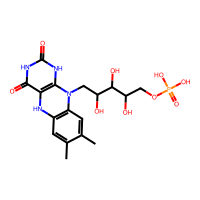

264


In [208]:
display(SVG(draw_molecule(unique_missed[i])))
print(missed_cts[unique_missed[i]])

i +=1

In [491]:
standardize_reaction(row['smarts'])

'CC(O)C(NC(=O)C(N)CO)C(=O)O.O>>NC(CO)C(=O)O.CC(O)C(N)C(=O)O'

In [106]:
i = 0
# _df = df
# _df = df.filter(pl.col("rxn_id").is_in(unmatched_pdts))

Row 2:
true reaction:


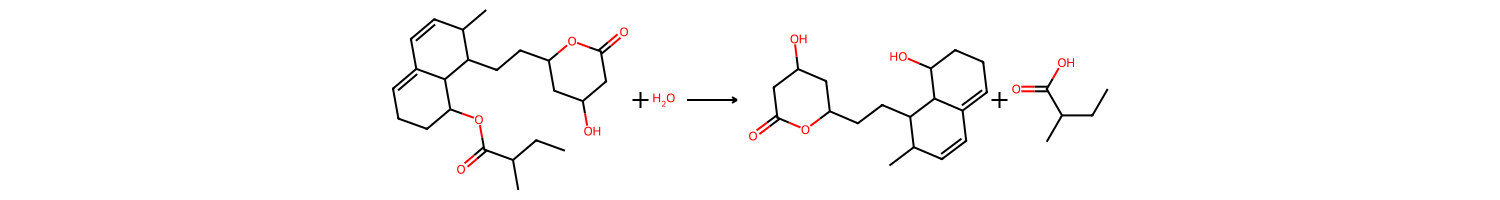

generated reaction:
Hash: c20558e8b57e576e52a79ee067650aca2608a640


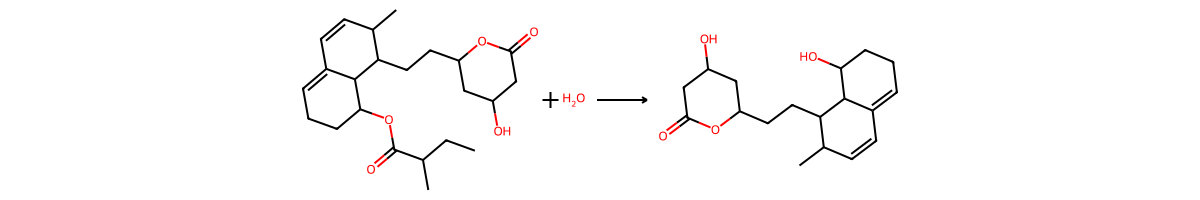

rule:


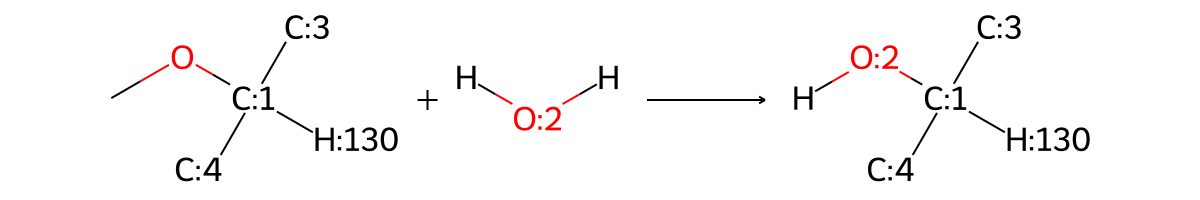

Gen rxn shows in pk expansion:
False

True reaction equals generated reaction:
False


In [109]:
row = df.row(i, named=True)
true_rxn = row['smarts_true']
gen_rxn = rm_hs(row['smarts'])
rule = row['rule']
gen_hash = standardize_and_hash(gen_rxn)

i +=1

print(f"Row {i}:")
print("true reaction:")
display(SVG(draw_reaction(true_rxn)))

print("generated reaction:")
print(f"Hash: {gen_hash}")
display(SVG(draw_reaction(gen_rxn)))

print("rule:")
display(SVG(draw_reaction(rule)))

print("Gen rxn shows in pk expansion:")
print(len(pred.filter(pl.col("id") == gen_hash)) > 0)

print("\nTrue reaction equals generated reaction:")
print(f"{true_rxn == gen_rxn}")

In [104]:
gen_rxn

'CCC(C)C(=O)OC1CCC=C2C=CC(C)C(CCC3CC(O)CC(=O)O3)C21>>CCC(C)C(=O)O'

In [110]:
row['rule_id']

'EVODEX.2-Em259'

In [111]:
row['rule']

'[#6:3]-[#6:1](-[#8]-[#6])(-[#6:4])-[#1:130].[#8:2](-[#1])-[#1]>>[#6:3]-[#6:1](-[#8:2]-[#1])(-[#6:4])-[#1:130]'

In [97]:
map_x_pk = df.join(pred, left_on="rxn_id", right_on="id", how="inner")

In [98]:
map_x_pk.shape

(70, 12)

In [ ]:
exceeds = set()
for row in df.iter_rows(named=True):
    lhs = row['smarts'].split(">>")[0]
    n_rcts = len(lhs.split("."))
    n_rule_rcts = len(row['rule'].split(">>")[0].split("."))
    if n_rule_rcts > n_rcts:
        exceeds.add(row["rxn_id"])

    n_pdts = len(smarts.split(">>")[1].split("."))
    n_rule_pdts = len(row['rule'].split(">>")[1].split("."))
    if n_rule_pdts > n_pdts:
        exceeds.add(row["rxn_id"])

print(len(exceeds))

36
